In [82]:
subs = [
    'sub-P10',
    'sub-P12',
    'sub-P13',
    'sub-P14',
    'sub-P15',
    'sub-P16',
    'sub-P17',
    'sub-P18',
    'sub-P19',
#    'sub-P20', Unattentive
    'sub-P21',
    'sub-P22',
    'sub-P23', 
    'sub-P25',    
# #        'sub-P26', missing event file
        'sub-P27',
# #        'sub-P30', incomplete data
    'sub-P31',
    'sub-P34',
    'sub-P35',
    'sub-P36',
    'sub-P37',
    'sub-P41',
    'sub-P42',
    'sub-P43',
    'sub-P44',
    'sub-P45',
    'sub-P47',
    'sub-P48',
# #        'sub-P49',   Unattentive
    'sub-P50',  
    'sub-P51',  
                    ]

In [83]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append('..')

In [84]:
results_path = '../data/processed/rsa/order_hippocampus/group_level/all_reps/rsa_results_run2.json'
results_euclidean_path = '../data/processed/rsa/order_hippocampus_euclidean/group_level/all_reps/rsa_results_run6.json'
group_level_results_path = '../data/processed/rsa/order_hippocampus/group_level/all_reps/rsa_results_run2_group_level_permutation.json'
results = pd.read_json(results_path).to_dict()
results_euclidean = pd.read_json(results_euclidean_path).to_dict()
group_level_results = pd.read_json(group_level_results_path).to_dict()

# RSA
## Main Results

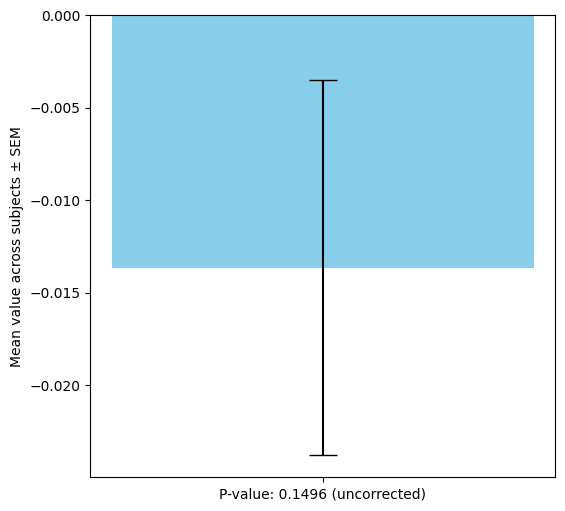

In [88]:
main_results = results['spat']
main_group_level_results = group_level_results['spatial']
# plot correlation values for euclidean and pearson
def plot_correlations(main_results, main_group_level_results):
    p_value = main_group_level_results['p_value']
    subjects = list(main_results.keys())
    spearman_values = [main_results[sub]['statistic'] for sub in subjects]
    spearman_sem = np.std(spearman_values) / np.sqrt(len(spearman_values))
    plt.figure(figsize=(6,6))
    plt.bar([0], np.mean(spearman_values), yerr=spearman_sem, capsize=10, color='skyblue')
    plt.xticks([0], [f'P-value: {p_value:.4f} (uncorrected)'])
    plt.ylabel('Mean value across subjects ± SEM')
    plt.show()
plot_correlations(main_results, main_group_level_results)

## Low and High Distances

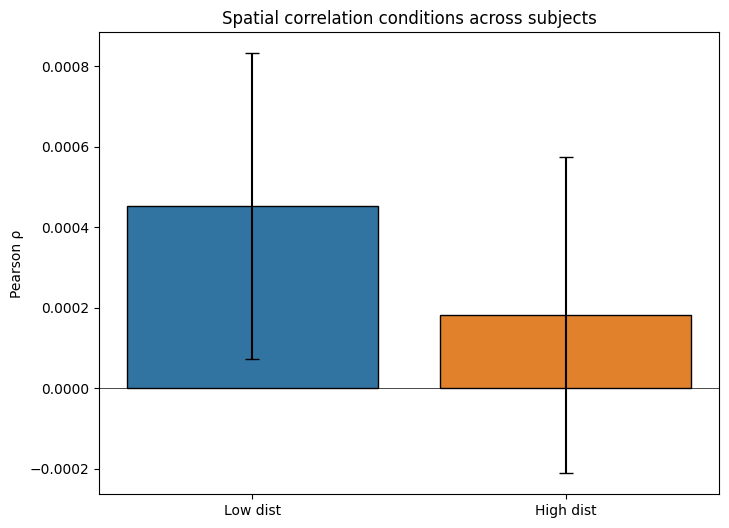

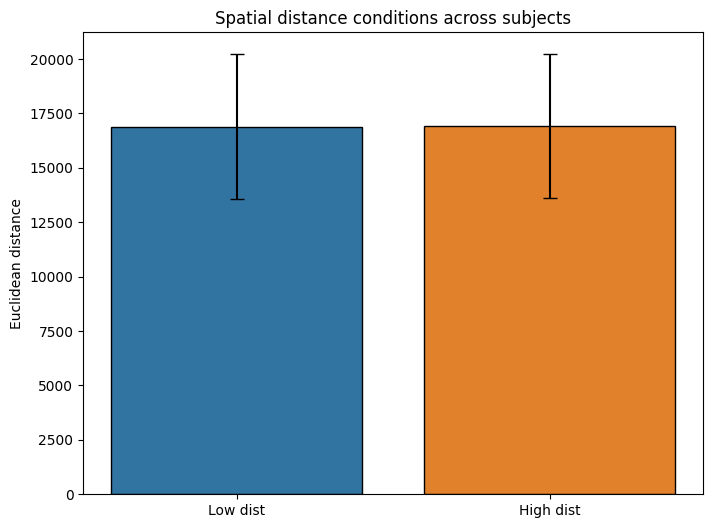

In [86]:
from scipy.stats import sem

def plot_low_and_high(results, euclidean=False):
    spat_low_corrs = results['spat_low']
    spat_high_corrs = results['spat_high']
    metric = "Euclidean distance" if euclidean else "Pearson ρ"
    value = "distance" if euclidean else "correlation"

    # --- Bar plot with SEM ---
    means = [
        np.mean(list(spat_low_corrs.values())),
        np.mean(list(spat_high_corrs.values()))
    ]
    sems = [
        sem(list(spat_low_corrs.values())),
        sem(list(spat_high_corrs.values()))
    ]

    plt.figure(figsize=(8,6))
    if not euclidean:
        plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    sns.barplot(
        x=['Low dist', 'High dist'],
        y=means,
        hue=['Low dist', 'High dist'],
        legend=False,
        capsize=0.2,
        edgecolor='black'
    )

    # Add SEM error bars manually
    plt.errorbar(
        x=[0, 1],
        y=means,
        yerr=sems,
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=1.5
    )

    plt.ylabel(metric)
    plt.title(f'Spatial {value} conditions across subjects')
    plt.show()

plot_low_and_high(results)
plot_low_and_high(results_euclidean, euclidean=True)

## Positive and Negative Effect

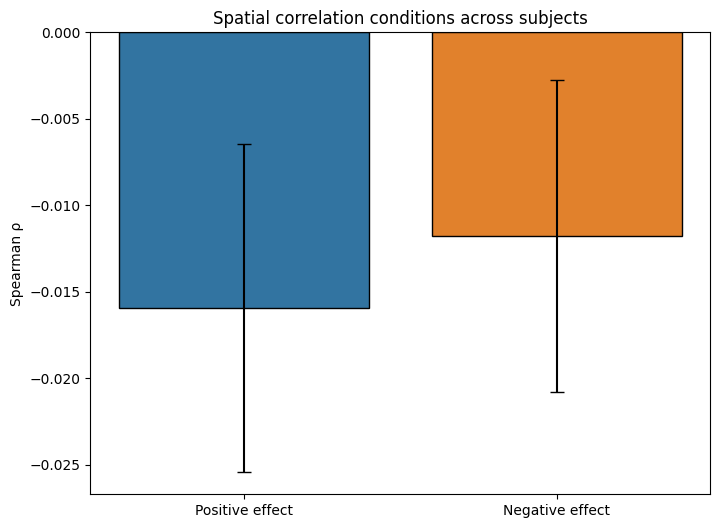

In [87]:
def plot_pos_and_low(results):
    pos_spat = [results['pos_spat'][sub]['statistic'] for sub in results['pos_spat']]
    neg_spat = [results['neg_spat'][sub]['statistic'] for sub in results['neg_spat']]
    
    # --- Bar plot with SEM ---
    means = [
        np.mean(list(pos_spat)),
        np.mean(list(neg_spat))
    ]
    sems = [
        sem(list(pos_spat)),
        sem(list(neg_spat))
    ]

    plt.figure(figsize=(8,6))
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    sns.barplot(
        x=['Positive effect', 'Negative effect'],
        y=means,
        hue=['Positive effect', 'Negative effect'],
        legend=False,
        capsize=0.2,
        edgecolor='black'
    )

    # Add SEM error bars manually
    plt.errorbar(
        x=[0, 1],
        y=means,
        yerr=sems,
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=1.5
    )

    plt.ylabel("Spearman ρ")
    plt.title(f'Spatial correlation conditions across subjects')
    plt.show()

plot_pos_and_low(results)
